# Problem Statement

The purpose of the case study is to classify a given silhouette as one of four different types of vehicle, using a set of features extracted from the silhouette. The vehicle may be viewed from one of many different angles.
Four &quot;Corgie&quot; model vehicles were used for the experiment: a double decker bus, Cheverolet
van, Saab 9000 and an Opel Manta 400 cars. This particular combination of vehicles was chosen with the expectation that the bus, van and either one of the cars would be readily distinguishable, but it would be more difficult to distinguish between the cars.
The purpose is to classify a given silhouette as one of three types of vehicle, using a set of features extracted from the silhouette. The vehicle may be viewed from one of many different angles.
 

The points distribution for this case is as follows:
1. Use a new Python notebook and read the data set. Data pre-processing - Understand the data and treat missing values (Use box plot), outliers (5 points)
2. Understanding the attributes - Find relationship between different attributes (Independent variables) and choose carefully which all attributes have to be a part of the analysis and why (5 points)
3. Use PCA from scikit learn and elbow plot to find out reduced number of dimension (which covers more than 95% of the variance) - 10 points
4. Use Support vector machines and use grid search (try C values - 0.01, 0.05, 0.5, 1 and kernel = linear, rbf) and find out the best hyper parameters and do cross validation to find the accuracy. (10 points)



# Load Data Set

In [26]:
from google.colab import drive
drive.mount('/content/drive')
BASE_PATH = "/content/drive/My Drive/aiml/GL/git/bangalore-feb-batch-smurli/R5/Project2-UnsupervisedLearning/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [0]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


from sklearn.decomposition import PCA
from scipy.stats import zscore

import warnings
warnings.filterwarnings('ignore')

In [28]:
df = pd.read_csv(BASE_PATH+"vehicle.csv")  
df.head()

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197,van
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199,van
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196,car
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207,van
4,85,44.0,70.0,205.0,103.0,52,149.0,45.0,19.0,144,241.0,325.0,188.0,127.0,9.0,11.0,180.0,183,bus


# Data Cleanup

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 19 columns):
compactness                    846 non-null int64
circularity                    841 non-null float64
distance_circularity           842 non-null float64
radius_ratio                   840 non-null float64
pr.axis_aspect_ratio           844 non-null float64
max.length_aspect_ratio        846 non-null int64
scatter_ratio                  845 non-null float64
elongatedness                  845 non-null float64
pr.axis_rectangularity         843 non-null float64
max.length_rectangularity      846 non-null int64
scaled_variance                843 non-null float64
scaled_variance.1              844 non-null float64
scaled_radius_of_gyration      844 non-null float64
scaled_radius_of_gyration.1    842 non-null float64
skewness_about                 840 non-null float64
skewness_about.1               845 non-null float64
skewness_about.2               845 non-null float64
hollows_ratio    

- The data set has 19 features and 846 records
- 'class' is the dependent feature
- All data types are correctly recognized 
- There are few NAs present in the data set

In [30]:
(df==0).sum()

compactness                     0
circularity                     0
distance_circularity            0
radius_ratio                    0
pr.axis_aspect_ratio            0
max.length_aspect_ratio         0
scatter_ratio                   0
elongatedness                   0
pr.axis_rectangularity          0
max.length_rectangularity       0
scaled_variance                 0
scaled_variance.1               0
scaled_radius_of_gyration       0
scaled_radius_of_gyration.1     0
skewness_about                 77
skewness_about.1               30
skewness_about.2                0
hollows_ratio                   0
class                           0
dtype: int64

There are some zero values in "skewness_about" and "skewness_about.1". These could be valid values, so lets leave them be.

In [31]:
df.isna().sum()

compactness                    0
circularity                    5
distance_circularity           4
radius_ratio                   6
pr.axis_aspect_ratio           2
max.length_aspect_ratio        0
scatter_ratio                  1
elongatedness                  1
pr.axis_rectangularity         3
max.length_rectangularity      0
scaled_variance                3
scaled_variance.1              2
scaled_radius_of_gyration      2
scaled_radius_of_gyration.1    4
skewness_about                 6
skewness_about.1               1
skewness_about.2               1
hollows_ratio                  0
class                          0
dtype: int64

There are some NAs in "skewness_about", "skewness_about.1" and "skewness_about.2". Since we consider zero values for these fields as valid values, lets replace NAs of these features with 0.

In [32]:
cols = ["skewness_about", "skewness_about.1", "skewness_about.2"]
df[cols] = df[cols].fillna(0)
df.isna().sum()

compactness                    0
circularity                    5
distance_circularity           4
radius_ratio                   6
pr.axis_aspect_ratio           2
max.length_aspect_ratio        0
scatter_ratio                  1
elongatedness                  1
pr.axis_rectangularity         3
max.length_rectangularity      0
scaled_variance                3
scaled_variance.1              2
scaled_radius_of_gyration      2
scaled_radius_of_gyration.1    4
skewness_about                 0
skewness_about.1               0
skewness_about.2               0
hollows_ratio                  0
class                          0
dtype: int64

- We have some NAs in area and radius related features. These values can not be zero and most likely it is a error in data entry or data collection.
- There are few NAs in "scaled" related features. Not sure what they exactly mean. 
- As the numbers of NAs are few in number, less than 5%, lets go ahead and drop them.

In [33]:
df = df.dropna()
df.isna().sum()

compactness                    0
circularity                    0
distance_circularity           0
radius_ratio                   0
pr.axis_aspect_ratio           0
max.length_aspect_ratio        0
scatter_ratio                  0
elongatedness                  0
pr.axis_rectangularity         0
max.length_rectangularity      0
scaled_variance                0
scaled_variance.1              0
scaled_radius_of_gyration      0
scaled_radius_of_gyration.1    0
skewness_about                 0
skewness_about.1               0
skewness_about.2               0
hollows_ratio                  0
class                          0
dtype: int64

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 817 entries, 0 to 845
Data columns (total 19 columns):
compactness                    817 non-null int64
circularity                    817 non-null float64
distance_circularity           817 non-null float64
radius_ratio                   817 non-null float64
pr.axis_aspect_ratio           817 non-null float64
max.length_aspect_ratio        817 non-null int64
scatter_ratio                  817 non-null float64
elongatedness                  817 non-null float64
pr.axis_rectangularity         817 non-null float64
max.length_rectangularity      817 non-null int64
scaled_variance                817 non-null float64
scaled_variance.1              817 non-null float64
scaled_radius_of_gyration      817 non-null float64
scaled_radius_of_gyration.1    817 non-null float64
skewness_about                 817 non-null float64
skewness_about.1               817 non-null float64
skewness_about.2               817 non-null float64
hollows_ratio    

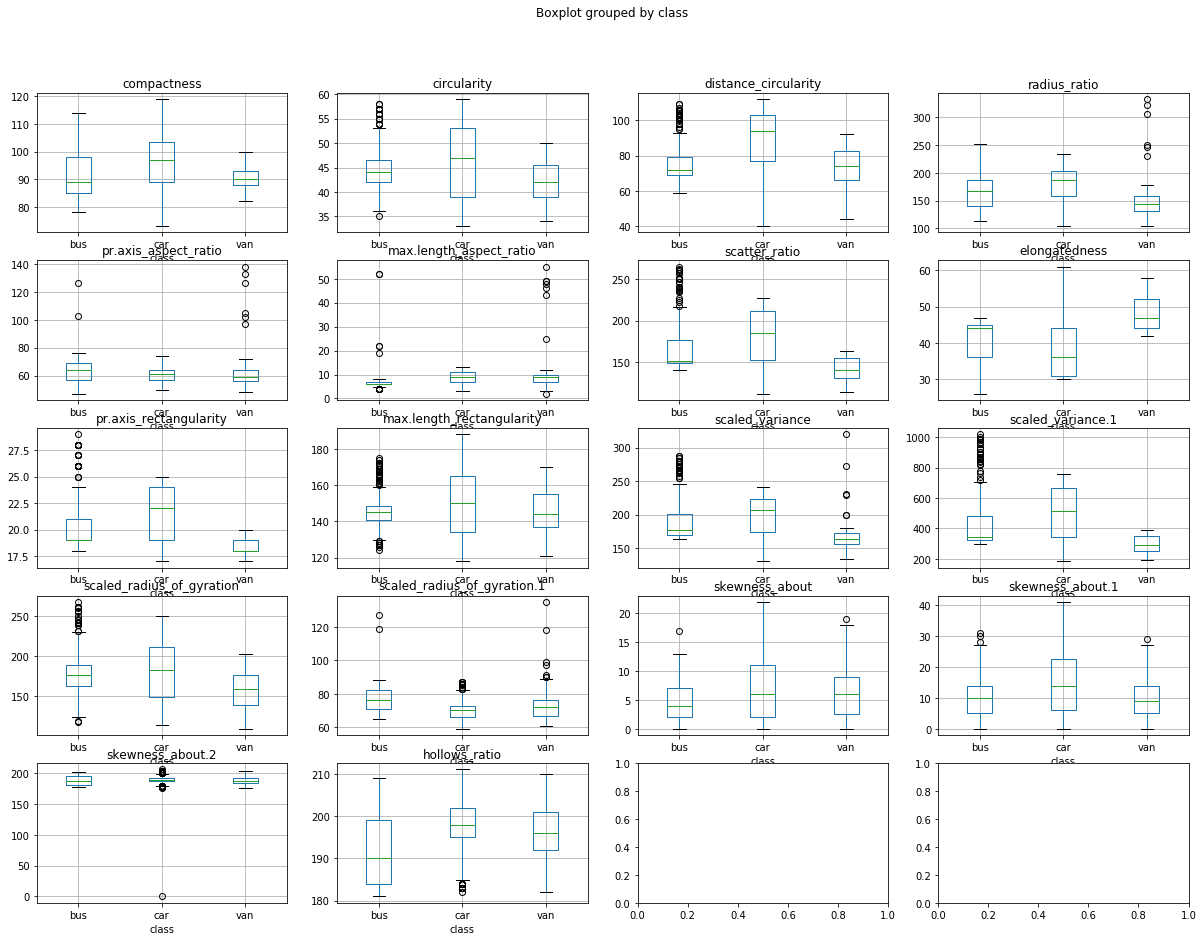

In [35]:
FIG_ROWS=5
FIG_COLS=4
fig, axes = plt.subplots(nrows=FIG_ROWS, ncols=FIG_COLS, figsize=(20,15))
row = 0
col = 0
for colum in df.drop("class",axis=1):
    df.boxplot(by="class",column=[colum], ax=axes[row,col] )
    col += 1
    row+=int(col/FIG_COLS)
    col=col%FIG_COLS


There are many outliers in the data set. Lets impute them.

In [0]:
data = df.copy()
       
def replace(group):
    median, std = group.median(), group.std()  #Get the median and the standard deviation of every group 
    outliers = (group - median).abs() > 3*std # Subtract median from every member of each group. Take absolute values > 3std
    group[outliers] = group.median()       
    return group


def imputeOutliers(data, groupByCol):
    data_corrected = (data.groupby(groupByCol).transform(replace)) 
    concat_data = data_corrected.join(pd.DataFrame(df[groupByCol]))
    return concat_data

data = imputeOutliers(data, "class")

Box Plot After Outlier Imputing


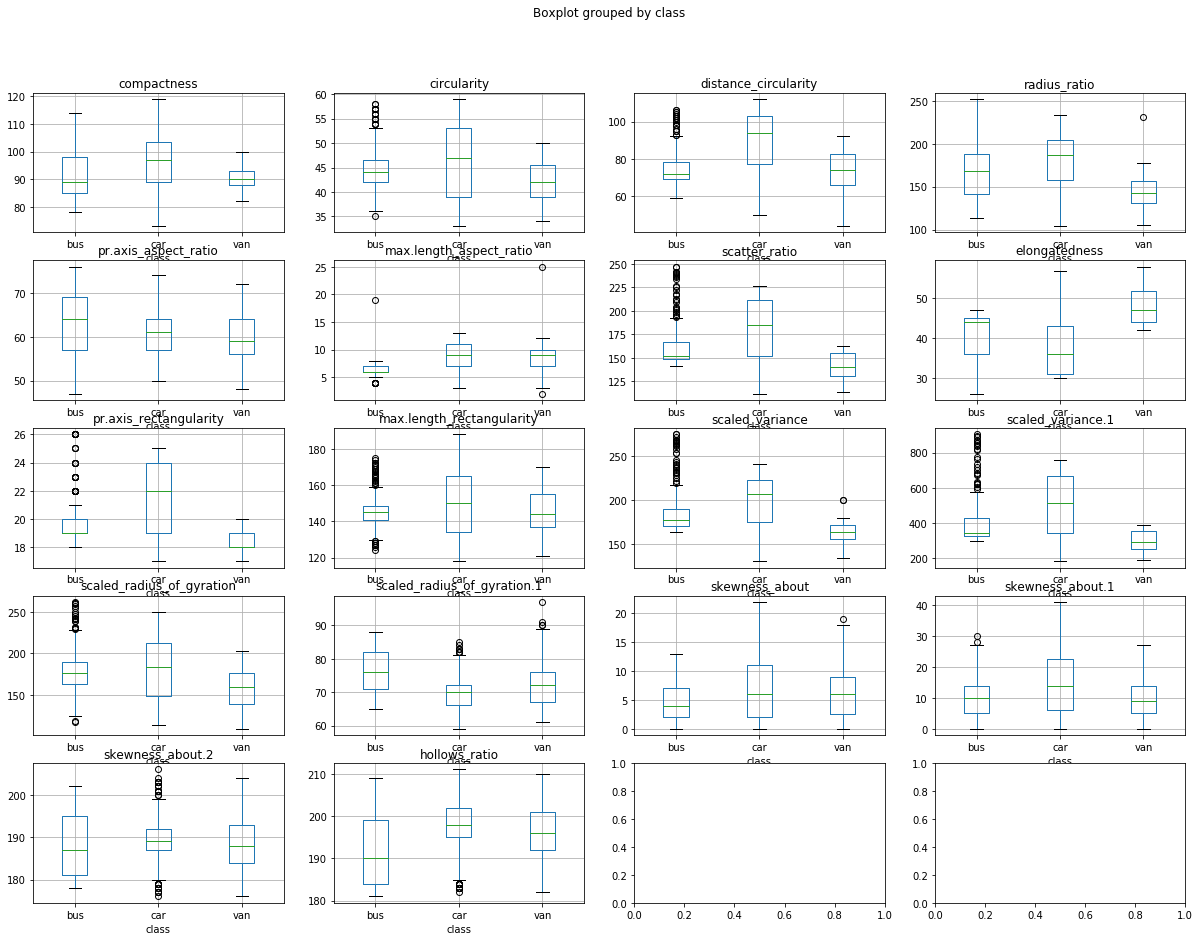

In [37]:
print("Box Plot After Outlier Imputing")
FIG_ROWS=5
FIG_COLS=4
fig, axes = plt.subplots(nrows=FIG_ROWS, ncols=FIG_COLS, figsize=(20,15))

row = 0
col = 0
for colum in data.drop("class",axis=1):
    data.boxplot(by="class",column=[colum], ax=axes[row,col] )
    col += 1
    row+=int(col/FIG_COLS)
    col=col%FIG_COLS

# Feature Selection

In [38]:
sns.pairplot(data)

Output hidden; open in https://colab.research.google.com to view.

We see multiple multicollinearity between features.

Lets check correlation index

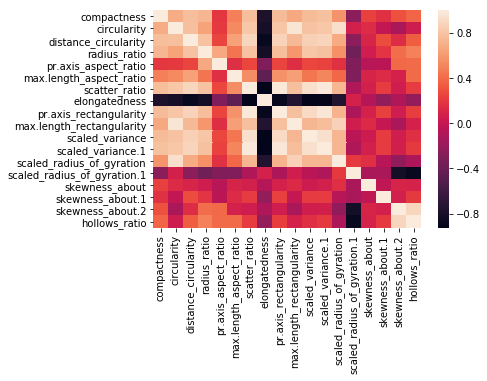

In [39]:
sns.heatmap(data.corr())

There seems to be high amount of possitive and negative correlation.

In [40]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def getVifMatrix(X):
    X_mat = X.as_matrix()
    vif = [ variance_inflation_factor( X_mat, i ) for i in range( X_mat.shape[1] ) ]
    vif_factors = pd.DataFrame()
    vif_factors['column'] = list(X.columns)
    vif_factors['vif'] = vif
    return vif_factors

dropCols = ["class"]
getVifMatrix(data.drop(dropCols,axis=1))

,column,vif
0,compactness,621.838279
1,circularity,2650.117830
2,distance_circularity,256.677614
3,radius_ratio,493.251889
4,pr.axis_aspect_ratio,522.367076
5,max.length_aspect_ratio,55.369088
6,scatter_ratio,2525.535344
7,elongatedness,295.818178
8,pr.axis_rectangularity,1869.440308
9,max.length_rectangularity,2812.311498


"hollows_ratio" and "skewness_about.2", seem to have high amount of correlation. Lets drop them.

In [41]:
dropCols = ["class", "skewness_about.2", "hollows_ratio"]
getVifMatrix(data.drop(dropCols,axis=1))


,column,vif
0,compactness,448.695800
1,circularity,2586.620475
2,distance_circularity,241.069367
3,radius_ratio,493.180638
4,pr.axis_aspect_ratio,472.514578
5,max.length_aspect_ratio,39.271968
6,scatter_ratio,2350.981207
7,elongatedness,182.589972
8,pr.axis_rectangularity,1843.430372
9,max.length_rectangularity,2653.410120


Lets drop "scatter_ratio" and "max.length_rectangularity" as well.

In [42]:
dropCols = ["class", "skewness_about.2", "hollows_ratio", "scatter_ratio", "max.length_rectangularity"]
getVifMatrix(data.drop(dropCols,axis=1))

,column,vif
0,compactness,424.132736
1,circularity,764.516081
2,distance_circularity,236.356963
3,radius_ratio,476.571186
4,pr.axis_aspect_ratio,462.070097
5,max.length_aspect_ratio,32.725521
6,elongatedness,176.324614
7,pr.axis_rectangularity,1134.210652
8,scaled_variance,564.987566
9,scaled_variance.1,181.880800


VIF looks better now. Still there are many variables with multicollinearity. Buts keep them and expect PCA would reduce some of the noises here. 

In [0]:
dropCols = ["class", "skewness_about.2", "hollows_ratio", "scatter_ratio", "max.length_rectangularity"]
y = data["class"]
X = data.drop(dropCols,axis=1)

# Train-Test Split

In [0]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=5, stratify=y)

# PCA

In [0]:
from sklearn.decomposition import PCA
sc = StandardScaler()
X_train_rescaled =  sc.fit_transform(X_train)          

[0.56156293 0.67845027 0.76181675 0.83879887 0.89311435 0.93165537
 0.95296595 0.97094714 0.98073497 0.98702792 0.99174399 0.995109
 0.99834651 1.        ]


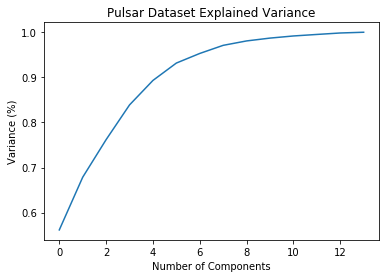

In [46]:
pca = PCA().fit(X_train_rescaled)

print(np.cumsum(pca.explained_variance_ratio_))
#Plotting the Cumulative Summation of the Explained Variance
plt.figure()
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Variance (%)') #for each component
plt.title('Pulsar Dataset Explained Variance')
plt.show()

7 PCA components are enough to explain 95% of the variance. So lets choose only 7 PCA components.

In [55]:
pca = PCA(n_components=7)
X_train_pca = pca.fit_transform(X_train_rescaled)
X_train_pca.shape

(653, 7)

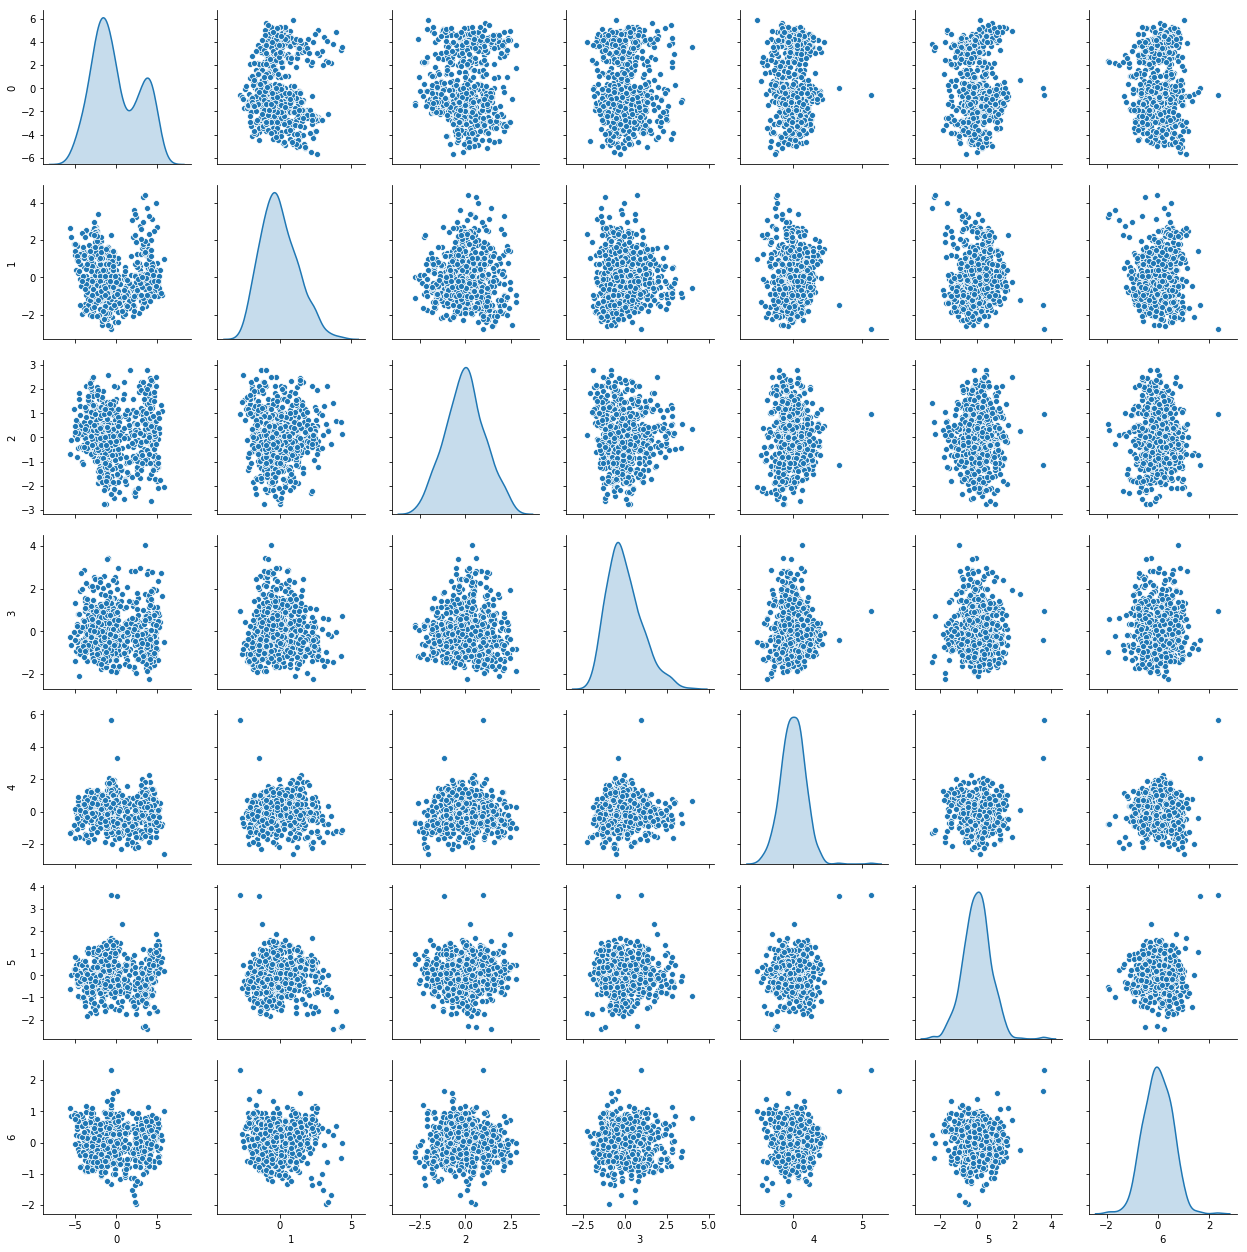

In [56]:
_ = sns.pairplot(pd.DataFrame(X_train_pca), diag_kind="kde")

WoW! This pair plot looks much better than the initial pair plot.

Multicollinearity are almost eliminated. Diagonal distribution plot looks much cleaner expect for first component where we see two cluster.

### Transform Test Data As well

In [0]:
X_test_rescaled =  sc.transform(X_test)
X_test_pca = pca.transform(X_test_rescaled)

# Hyper Parameter Tuning

Lets quickly check the model performance with default parameters between PCA and PCA applied data

In [76]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import SVC


svc_model = SVC()
svc_model.fit(X_train, y_train)

predic = svc_model.predict(X_test)
print("Model Score for Train",svc_model.score(X_train, y_train))
print("Model Score for Test",svc_model.score(X_test, y_test))

print(classification_report(y_test,predic))
print(confusion_matrix(y_test, predic))


Model Score for Train 1.0
Model Score for Test 0.5121951219512195
              precision    recall  f1-score   support

         bus       0.00      0.00      0.00        42
         car       0.51      1.00      0.67        83
         van       1.00      0.03      0.05        39

    accuracy                           0.51       164
   macro avg       0.50      0.34      0.24       164
weighted avg       0.50      0.51      0.35       164

[[ 0 42  0]
 [ 0 83  0]
 [ 0 38  1]]


Without PCA and default parameters, the model is clearly overfitting.

In [77]:
svc_model = SVC()
svc_model.fit(X_train_pca, y_train)

predic = svc_model.predict(X_test_pca)
print("Model Score for Train",svc_model.score(X_train_pca, y_train))
print("Model Score for Test",svc_model.score(X_test_pca, y_test))

print(classification_report(y_test,predic))
print(confusion_matrix(y_test, predic))


Model Score for Train 0.9433384379785605
Model Score for Test 0.9390243902439024
              precision    recall  f1-score   support

         bus       0.95      0.95      0.95        42
         car       0.95      0.94      0.95        83
         van       0.90      0.92      0.91        39

    accuracy                           0.94       164
   macro avg       0.93      0.94      0.94       164
weighted avg       0.94      0.94      0.94       164

[[40  2  0]
 [ 1 78  4]
 [ 1  2 36]]


With PCA and default parameters the model's variance error has come down.

Lets do a GridSearch to find optimal hyper parameters for SVC. Along with the C values specified in problem statement lets include C = 10 and 100 as well.

In [0]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C':[0.01,0.05,0.5,1,10,100], 'kernel':['linear','rbf']}
grid = GridSearchCV(SVC(),param_grid,refit = True, cv=3)

In [93]:
grid.fit(X_train_pca,y_train)

GridSearchCV(cv=3, error_score='raise-deprecating',
             estimator=SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
                           decision_function_shape='ovr', degree=3,
                           gamma='auto_deprecated', kernel='rbf', max_iter=-1,
                           probability=False, random_state=None, shrinking=True,
                           tol=0.001, verbose=False),
             iid='warn', n_jobs=None,
             param_grid={'C': [0.01, 0.05, 0.5, 1, 10, 100],
                         'kernel': ['linear', 'rbf']},
             pre_dispatch='2*n_jobs', refit=True, return_train_score=False,
             scoring=None, verbose=0)

In [94]:
grid.best_params_

{'C': 10, 'kernel': 'rbf'}

In [95]:
predic = grid.predict(X_test_pca)
print("Model Score for Train",grid.score(X_train_pca, y_train))
print("Model Score for Test",grid.score(X_test_pca, y_test))

print(classification_report(y_test,predic))
print(confusion_matrix(y_test, predic))


Model Score for Train 0.9846860643185299
Model Score for Test 0.9451219512195121
              precision    recall  f1-score   support

         bus       0.98      0.95      0.96        42
         car       0.94      0.95      0.95        83
         van       0.92      0.92      0.92        39

    accuracy                           0.95       164
   macro avg       0.95      0.94      0.94       164
weighted avg       0.95      0.95      0.95       164

[[40  2  0]
 [ 1 79  3]
 [ 0  3 36]]


The optimal parameters are giving better results compared to default hyper parameters.